<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/4%20Hyperparameter%20Tuning/2_LR_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, GridSearchCV


Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df


,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0


In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df


,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,...,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Initialize

In [13]:
lor = LogisticRegression()


Hyperparameter Tuning

In [14]:
param_lo = {'penalty': ['l1', 'l2'],
            'C': [2**_ for _ in range(-15,11)],
            'solver': ['liblinear']}

gs_lo = GridSearchCV(lor, param_lo, cv=5, scoring='accuracy')
%time gs_lo.fit(X, y01)
print(gs_lo.best_params_)
print(gs_lo.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CPU times: user 2.01 s, sys: 2.98 ms, total: 2.02 s
Wall time: 2.02 s
{'C': 0.5, 'penalty': 'l1', 'solver': 'liblinear'}
0.820360824742268


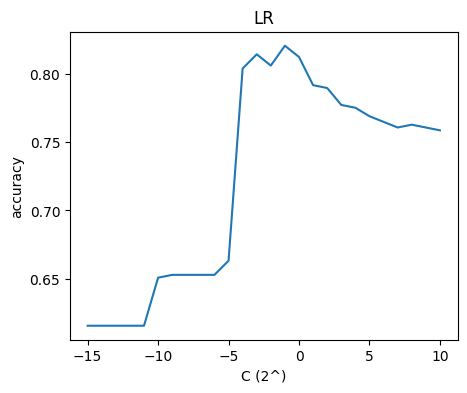

In [15]:
param_lo = {'C': [2**_ for _ in range(-15,11)],
            'penalty': ['l1'],
            'solver': ['liblinear']}
gs_lo = GridSearchCV(lor, param_lo, cv=5, scoring='accuracy')
gs_lo.fit(X, y01)

plt.figure(figsize=(5, 4))
plt.plot(range(-15,11), gs_lo.cv_results_['mean_test_score'])

plt.xlabel('C (2^)')
plt.ylabel('accuracy')
plt.title('LR')

plt.show()

In [16]:
param_lo = {'C': [0.5],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']}
gs_lo = GridSearchCV(lor, param_lo, cv=5, scoring='accuracy')
gs_lo.fit(X, y01)
print(gs_lo.cv_results_['mean_test_score'])

print(gs_lo.cv_results_['params'])

[0.82036082 0.78125   ]
[{'C': 0.5, 'penalty': 'l1', 'solver': 'liblinear'}, {'C': 0.5, 'penalty': 'l2', 'solver': 'liblinear'}]


In [17]:
param_lo = {'penalty': [None],
            'max_iter': [1000]}
gs_lo = GridSearchCV(lor, param_lo, cv=5, scoring='accuracy')
gs_lo.fit(X, y01)
print(gs_lo.cv_results_['mean_test_score'])

print(gs_lo.cv_results_['params'])

[0.76473368]
[{'max_iter': 1000, 'penalty': None}]
